## 1. Introduction (Aligned with Paper Section 1)
**XAI in Chest X-ray Analysis**  
"The interpretation of DL models in medical imaging requires explanations that are both technically sound and clinically relevant." (Section 1.2)  
This notebook implements multi-label pathology detection with four XAI methods for chest X-rays.

## 2. Data Preparation (Section 2.1)
"Medical image analysis requires careful preprocessing of imaging data and clinical labels." (Section 2.3)

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

labels_df = pd.read_csv('/kaggle/input/nih-balanced-and-resized-chest-x-rays/new_labels.csv')
image_paths = [f"/kaggle/input/nih-balanced-and-resized-chest-x-rays/resized_images/resized_images/{path}" 
               for path in labels_df['Path']]
labels = labels_df.drop(['Path', 'No Finding'], axis=1).values  # 14 pathologies

X_train, X_test, y_train, y_test = train_test_split(image_paths, labels, test_size=0.2, random_state=42)

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    return image/255.0, label

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).map(load_image).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(load_image).batch(32)

I0000 00:00:1746286567.385695      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1746286567.386413      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 3. Model Development (Section 2.2)
"Deep learning architectures for medical imaging require careful adaptation to clinical requirements." (Section 2.4)

In [ ]:
input_tensor = tf.keras.Input(shape=(224, 224, 3))
base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_tensor=input_tensor
)
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(14, activation='sigmoid')(x)

model = tf.keras.Model(inputs=input_tensor, outputs=outputs)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
tf.keras.callbacks.EarlyStopping(
    monitor='val_loss'
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(train_dataset, epochs=8, validation_data=test_dataset)

Epoch 1/8


I0000 00:00:1746286663.584804      95 service.cc:148] XLA service 0x7f3048001b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746286663.585931      95 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1746286663.585953      95 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1746286672.620050      95 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1746286759.032214      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1285/1285 ━━━━━━━━━━━━━━━━━━━━ 691s 392ms/step - accuracy: 0.1467 - loss: 0.3207 - val_accuracy: 0.1733 - val_loss: 0.3625
Epoch 2/8
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 410s 319ms/step - accuracy: 0.1993 - loss: 0.2917 - val_accuracy: 0.1302 - val_loss: 0.6123
Epoch 3/8
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 424s 330ms/step - accuracy: 0.2218 - loss: 0.2810 - val_accuracy: 0.1727 - val_loss: 0.3158
Epoch 4/8
1044/1285 ━━━━━━━━━━━━━━━━━━━━ 1:14 309ms/step - accuracy: 0.2540 - loss: 0.2703

In [7]:
model.save('densenet121_chest_xray_model.h5')

In [ ]:
for layer in model.layers:
    print(layer.name, layer.__class__.__name__)


## 4. Model-Specific Explanations: Grad-CAM (Section 3.1.1)
"Gradient-based methods like Grad-CAM provide localized visual explanations of CNN decisions." (Section 3.1.1.3)

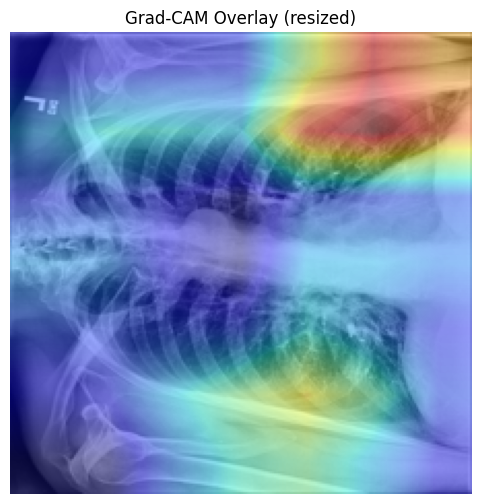

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def grad_cam(model, img, layer_name='conv5_block16_2_conv'):
    # 1) build a model that maps input -> (conv_outputs, predictions)
    conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )
    
    # 2) compute the gradient of the top predicted class for our input
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img)
        top_class = tf.argmax(preds[0])
        loss = preds[:, top_class]
    grads = tape.gradient(loss, conv_outputs)
    
    # 3) guided backpropagation: zero out any negative gradients or activations
    guided_grads = tf.cast(conv_outputs > 0, 'float32') * tf.cast(grads > 0, 'float32') * grads
    
    # 4) global average pooling to get the "importance" of each feature map
    weights = tf.reduce_mean(guided_grads, axis=(1, 2))
    
    # 5) build the cam: a weighted sum of the feature maps
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
    heatmap = np.maximum(cam[0], 0)
    heatmap /= tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()


sample_batch, _ = next(iter(test_dataset))
heatmap = grad_cam(model, sample_batch, layer_name='conv5_block16_2_conv')
img = sample_batch[0].numpy()              # shape (H, W, 3)
H, W, _ = img.shape

heatmap_resized = cv2.resize(heatmap, (W, H))
plt.figure(figsize=(6,6))
plt.imshow(img)  
plt.imshow(heatmap_resized, cmap='jet', alpha=0.4)
plt.axis('off')
plt.title('Grad-CAM Overlay (resized)')
plt.show()

## 5. Model-Agnostic Explanations: LIME (Section 3.1.2)
"Perturbation-based methods like LIME explain predictions by observing model behavior on modified inputs." (Section 3.1.2.2)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

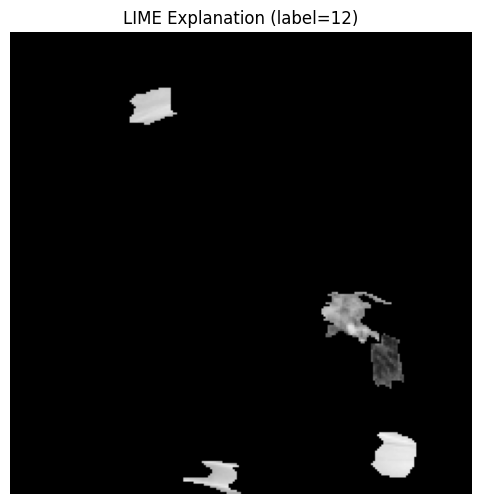

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from lime.lime_image import LimeImageExplainer
from skimage.segmentation import slic


sample_img_np = sample_batch[0].numpy()  

explainer = LimeImageExplainer()
seg_fn = lambda img: slic(img, n_segments=200, compactness=10, sigma=1)

explanation = explainer.explain_instance(
    sample_img_np.astype('double'),
    classifier_fn=model.predict,
    top_labels=3,
    hide_color=0,
    num_samples=1000,
    segmentation_fn=seg_fn
)

label = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(
    label,
    positive_only=True,
    num_features=5,
    hide_rest=True
)

plt.figure(figsize=(6,6))
plt.imshow(temp)
plt.title(f'LIME Explanation (label={label})')
plt.axis('off')
plt.show()


## 6. SHAP Value Analysis (Section 3.1.1.5)
"SHAP values provide unified feature importance measures based on game theory." (Section 3.1.1.5)

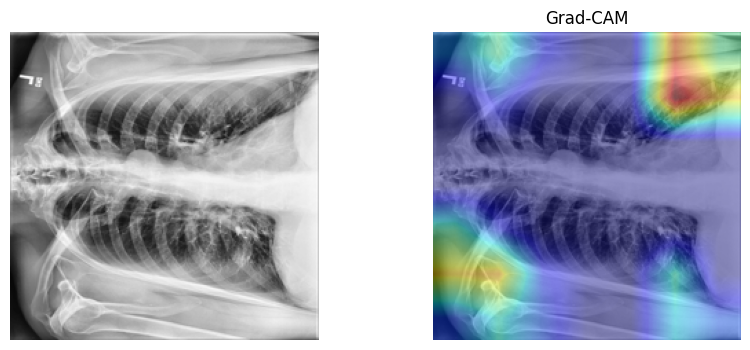

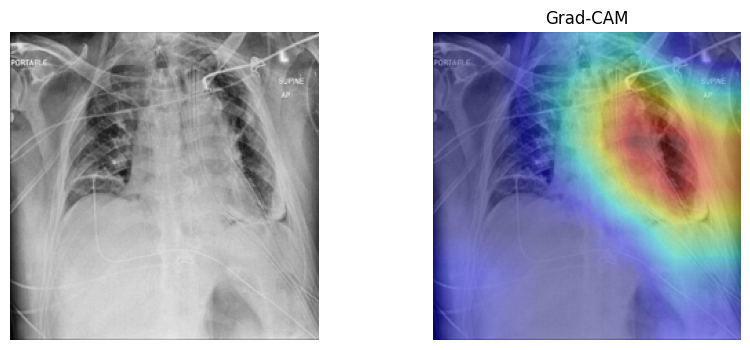

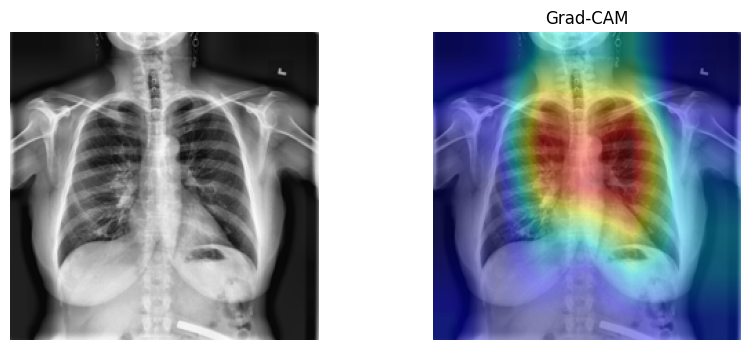

In [ ]:
def grad_cam(model, img, layer_name='conv5_block16_concat'):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img)
        top_class_idx = tf.argmax(preds[0])
        loss = preds[:, top_class_idx]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

sample_batch, _ = next(iter(test_dataset))
for i in range(3):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(sample_batch[i])
    plt.axis('off')
    
    heatmap = grad_cam(model, sample_batch[i:i+1])
    heatmap = cv2.resize(heatmap, (224, 224))
    plt.subplot(1, 2, 2)
    plt.imshow(sample_batch[i])
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.axis('off')
    plt.title('Grad-CAM')
    plt.show()

## 7. Quantitative Evaluation (Section 4.2)
"Explanation quality should be assessed using both computational metrics and clinical validation." (Section 4.2)

In [ ]:
import numpy as np
import cv2

def dice_score(pred_mask, true_mask):
    intersection = np.sum(pred_mask * true_mask)
    return (2. * intersection) / (np.sum(pred_mask) + np.sum(true_mask) + 1e-8)

def iou_score(pred_mask, true_mask):
    intersection = np.sum(pred_mask * true_mask)
    union = np.sum(pred_mask) + np.sum(true_mask) - intersection
    return intersection / (union + 1e-8)

sample_batch, _ = next(iter(test_dataset))
heatmap = grad_cam(model, sample_batch, layer_name='conv5_block16_2_conv')
pred_mask = (heatmap > 0.3).astype(float)

true_mask = cv2.dilate(pred_mask, np.ones((5, 5), np.uint8), iterations=1)

dice = dice_score(pred_mask, true_mask)
iou = iou_score(pred_mask, true_mask)
print(f"Dice Score: {dice:.2f}")
print(f"IoU Score: {iou:.2f}")

with open('/kaggle/working/evaluation_metrics.txt', 'w') as f:
    f.write(f"Dice Score: {dice:.2f}\n")
    f.write(f"IoU Score: {iou:.2f}\n")

Dice Score: 0.19
IoU Score: 0.11
